<a href="https://colab.research.google.com/github/rosacarla/inovacao-2ds/blob/main/Revis%C3%A3o3_Aprendizado_de_M%C3%A1quina_por_Refor%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 **Desafio Prático: Aprendizado de Máquina por Reforço**  
Nesta revisão, você atuará como desenvolvedor de IA.  
Para começar, <font color="red"><b>salve uma cópia deste notebook no seu Drive.</b></font>   
<br>
  


⚠️ USE A SUA CÓPIA DO ARQUIVO PARA PREENCHER E ENTREGAR A TAREFA!   
⚠️ LEIA AS INSTRUÇÕES DE CADA CÉLULA E FAÇA TUDO NA ORDEM QUE ESTÁ!   
<BR>   


Complete os blocos de código como é indicado nos comentários para resolver problema real usando um algoritmo de aprendizado de máquina por reforço (exemplificado no infográfico).      
<BR>

### **Aprendizado por Reforço (O Equilibrista)**

<p align="justify">
Contexto: Utilizaremos um ambiente de simulação para jogos chamado <i>CartPole</i>, que funciona como um console de videogame onde o jogador não é você, mas é IA. O objetivo é equilibrar um poste (<i>Pole</i>) sobre um carrinho (<i>Cart</i>) em movimento através de tentativa e erro, como se observa no Gif a seguir. A IA recebe recompensas (+1 ponto) por cada segundo de sucesso e aprende sozinha a melhor estratégia de movimento, simulando como robôs reais aprendem a manter o equilíbrio sem um manual de instruções prévio. </p>  

![CartPole em ação](https://pytorch.org/tutorials/_images/cartpole.gif)

In [1]:
# CLIQUE NO BOTÃO PLAY PARA EXECUTAR A CÉLULA
# Instala e importa as bibliotecas necessárias do Python
!pip install gymnasium # baixa e instala o simulador "Gymnasium" no Google Colab
import gymnasium as gym # fornece o ambiente de jogo (como o CartPole) para a IA treinar
import matplotlib.pyplot as plt # desenha os gráficos de desempenho do robô

# Cria o ambiente CartPole
env = gym.make("CartPole-v1", render_mode="rgb_array")
obs, info = env.reset()

# Se aparecer um ícone verde de conferido ao lado do botão play, a execução deu certo.

In [3]:
# COMPLETE O BLOCO DE CONDIÇÕES DA LÓGICA DE MOVIMENTO

# --- DESAFIO 3 ---
# 1. Criar uma lista para armazenar o histórico de pontos.
# 2. Definir observation[2] como inclinação do poste.
# 3. Definir as condições da lógica de movimento: se for menor que 0,
# mova para esquerda (action = 0).
# 4. Se for maior ou igual a 0, mova para direita (action = 1).
# 5. Acumular a recompensa a cada passo da simulação.

# Criação da LISTA para o histórico
historico_pontos = []
pontuacao_acumulada = 0
obs, info = env.reset()

# Laço de repetição do aprendizado
for _ in range(200):
    # Define a INCLINAÇÃO baseada na observação[2]
    inclinacao = obs[2]

    # COMPLETE A LÓGICA DE MOVIMENTO
    if inclinacao < 0:
        action = 0 # Mover para esquerda
    else:
        action = 1 # Mover para direita

    # Executa a ação no ambiente e recebe os dados
    obs, reward, terminated, truncated, info = env.step(action)
    pontuacao_acumulada += reward
    historico_pontos.append(pontuacao_acumulada)

    # Se o jogo acabar, reinicia o ambiente
    if terminated or truncated:
        obs, info = env.reset()

# CLIQUE NO BOTÃO PLAY PARA EXECUTAR A CÉLULA
# Se aparecer um ícone verde de conferido ao lado do botão play, a execução deu certo.

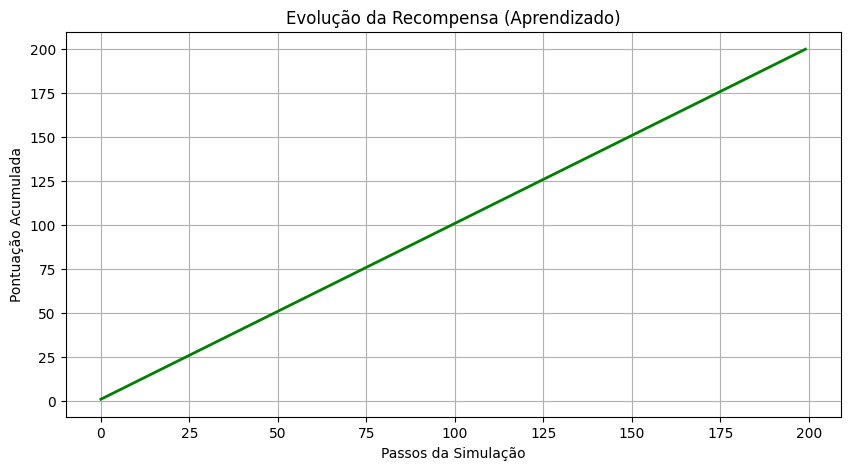

Simulação concluída! Veja no gráfico acima como a recompensa subiu 👆. Mas veja, nós programamos a solução. A máquina não aprendeu nada, ela só obedeceu a nossa lógica clássica.


In [4]:
# CLIQUE NO BOTÃO PLAY PARA EXECUTAR A CÉLULA E VER O GRÁFICO

# Gera gráfico de linha para visualizar a evolução do aprendizado
plt.figure(figsize=(10, 5))
plt.plot(historico_pontos, color='green', linewidth=2)
plt.title('Evolução da Recompensa (Aprendizado)')
plt.xlabel('Passos da Simulação')
plt.ylabel('Pontuação Acumulada')
plt.grid(True)
plt.show()

print("Simulação concluída! Veja no gráfico acima como a recompensa subiu 👆. Mas veja, nós programamos a solução. A máquina não aprendeu nada, ela só obedeceu a nossa lógica clássica.")

In [8]:
# PARTE 1 - TREINAMENTO DE MODELO DE IA POR APRENDIZADO DE REFORÇO
# 1. Instala as bibliotecas necessárias para rodar jogos e gerar vídeos no Colab
!pip install gymnasium stable-baselines3[extra] moviepy > /dev/null
from stable_baselines3 import PPO # PPO é o algoritmo de IA (Aprendizado por Reforço) que aprenderá a jogar sozinho
from gymnasium.utils.save_video import save_video # ferramenta para gravar e salvar as tentativas da IA em formato de vídeo

# 2. Cria ambiente para treino (sem mostrar vídeo para ir mais rápido)
env_treino = gym.make("CartPole-v1")

# 3. Cria a IA Real (PPO)
# Muda o verbose para 1 para visualização das tabelas do treino na tela
modelo_ia = PPO("MlpPolicy", env_treino, verbose=1)

print("🏋️ O TREINAMENTO COMEÇOU! Preste atenção nos dados que vão aparecer na tela...")
print("Monitore a métrica 'ep_len_mean' (média de tempo que o mastro ficou de pé). Ela deve subir!\n")

# A IA vai treinar por 20.000 passos de uma vez e mostrará o relatório a cada bloco
modelo_ia.learn(total_timesteps=20000)
env_treino.close()

print("\n🎉 Treinamento concluído com sucesso!")
print("🎬 Vamos gravar um vídeo para assistir a IA treinada em ação...")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
🏋️ O TREINAMENTO COMEÇOU! Preste atenção nos dados que vão aparecer na tela...
Monitore a métrica 'ep_len_mean' (média de tempo que o mastro ficou de pé). Ela deve subir!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.5     |
|    ep_rew_mean     | 22.5     |
| time/              |          |
|    fps             | 1280     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 26          |
|    ep_rew_mean          | 26          |
| time/                   |             |
|    fps                  | 928         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/        

In [9]:
# PARTE 2 - GRAVAÇÃO DA IA TREINADA JOGANDO
# Cria novo ambiente configurado para gravar o vídeo do resultado
env_video = gym.make("CartPole-v1", render_mode="rgb_array_list")
obs, info = env_video.reset()
terminated = False
truncated = False

while not (terminated or truncated):
    # Agora a IA usa o "cérebro" que acabou de treinar para decidir
    action, _states = modelo_ia.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_video.step(action)

# Salva o vídeo do sucesso do treino na pasta do Colab
save_video(
    env_video.render(),
    "videos",
    fps=30,
    episode_index=0,
    name_prefix="ia_treinada_com_sucesso"
)

env_video.close()
print("\n🎥 Vídeo gerado! Abra a pasta 'videos' no menu esquerdo para assistir à IA equilibrando o mastro perfeitamente!")


🎥 Vídeo gerado! Abra a pasta 'videos' no menu esquerdo para assistir à IA equilibrando o mastro perfeitamente!


🎉 Parabéns por chegar até aqui!  
- Salve o seu arquivo clicando no menu "Arquivo/Salvar e fixar revisão".  
- Desbloqueie o link pelo botão azul "Compartilhar", na opção "Acesso geral/Qualquer pessoa com o link".
- Copie o link desbloqueado deste notebook como resposta do exercício no Classroom.  
- Clique em "Arquivo/Salvar uma cópia no Github", selecione o repositorio <b>inovacao-2ds</b> e OK.